## 1. Introduction


**Project title:** `Retail Sales Trend Analysis`    
**Student name:** `Aditya Makkar`  
**Module:** M504 AI and Applications  

**Client company / stakeholder:** Aditya's Retail Store
* **Business Problem:** The data is a collection of various purchases made at the retail store. The data contains missing values, and inconsistent records. This makes performing data analysis difficult, and makes it difficult for the companies' management to make reliable decisions, or analyze its past trends.

* **Objective:** As a Data Science Consultant, I plan to reconstruct the missing transaction data using mathematical deduction, followed by EDA to present actionable insights to the management of the company, regarding top-selling items, store performance, and customer spending habits. This analysis can further be used by the retail store for future planning and strategy. 



## 2. References and credits

**Dataset name:** `Retail Store Sales: Dirty for Data Cleaning`  
**Dataset URL:** `https://www.kaggle.com/datasets/ahmedmohamed2003/retail-store-sales-dirty-for-data-cleaning/data`  
* **Sidenote:** This is a dataset littered with missing values, and inconsistencies, simulating a real life case which would be tackled by Data Scientists



## 3. Data Summary and Overview


**Dataset Architecture**: The dataset contains exactly 12575 individual retail transactions across 11 distinct features/columns.

**Data Integrity (Duplicates)**: There are zero duplicates, indicating that all rows/transactions are unique. This is further confirmed with getting 12575 unique values for transaction IDs.

**Feature Anatomy**: The 11 columns are a mixture of categorical dimensions (like location and payment method) and financial data. 

However, to gain a deeper understanding of the dataset, we're going to feature engineer other columns to gain a comprehensive overveiw of the dataset.


## 4. Missing Value Analysis

PART 3: MISSING VALUES ANALYSIS


,Non-Null Count,Null Count,Missing %
discount_applied,8376,4199,33.39
item,11362,1213,9.65
price_per_unit,11966,609,4.84
quantity,11971,604,4.80
total_spent,11971,604,4.80


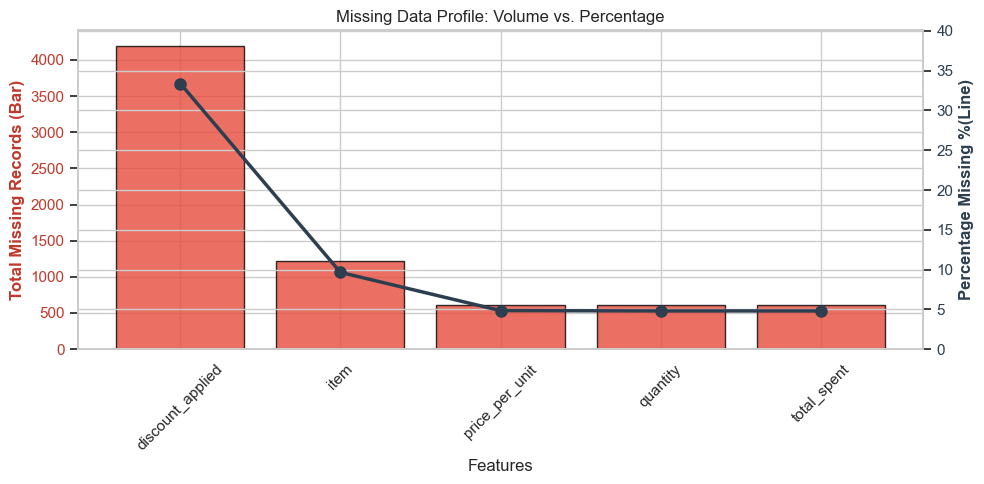

In [ ]:
print("PART 3: MISSING VALUES ANALYSIS")
missing_metadata = pd.DataFrame({
    "Non-Null Count": df_retail.notnull().sum(),
    "Null Count": df_retail.isnull().sum(),
    "Missing %": (df_retail.isnull().sum() / len(df_retail) * 100).round(2)
})

missing_table = missing_metadata[missing_metadata['Null Count'] > 0].sort_values(by='Null Count', ascending=False)
display(missing_table)

if not missing_table.empty:
    fig, ax1 = plt.subplots(figsize=(10, 5))

    ax1.bar(missing_table.index, missing_table['Null Count'], color='#e74c3c', edgecolor='black', alpha=0.8, label='Null Count')
    ax1.set_xlabel('Features')
    ax1.set_ylabel('Total Missing Records (Bar)', color='#c0392b', fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='#c0392b')
    ax1.tick_params(axis='x', rotation=45)

    ax2 = ax1.twinx()
    ax2.plot(missing_table.index, missing_table['Missing %'], color='#2c3e50', marker='o', linestyle='-', linewidth=2.5, markersize=8, label='Missing %')
    ax2.set_ylabel('Percentage Missing %(Line)', color='#2c3e50', fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='#2c3e50')
    
    ax2.set_ylim(0, max(missing_table['Missing %']) * 1.2)

    plt.title('Missing Data Profile: Volume vs. Percentage')
    fig.tight_layout()
    plt.show()

**Key Takeaways from this Analysis-**

1.) `Discount` Applied has 33% NaN values. This will be treated as no discount availed as this is a standard retail dataset, and would indicate so.

2.) For items, heres the step by step process we'll do to compute the missing values. 

(Step 1: Build a dictionary matching prices to `items` (based on the values from the rows with values/uncorrupted rows) -> Step 2: Calculate the missing numbers using Total = Quantity * Price -> Step 3: Look up the missing item names using those newly calculated prices.)

3.) For rows with NaN in both `quantity` and `total spend`, we will drop those rows.

## 5) Data Preproceesing and cleaning


In [79]:
import pandas as pd
import numpy as np
from IPython.display import display

pd.set_option('future.no_silent_downcasting', True)

print("PART 4: DATA PREPROCESSING & DETERMINISTIC IMPUTATION")
df_clean = df_retail.copy()

df_clean['transaction_date'] = pd.to_datetime(df_clean['transaction_date'])

text_cols = ['category', 'payment_method', 'location', 'item']
for col in text_cols:
    df_clean[col] = df_clean[col].str.strip().str.title()

df_clean['discount_applied'] = df_clean['discount_applied'].fillna(False).astype(bool)

valid_items = df_clean.dropna(subset=['category', 'price_per_unit', 'item'])
price_map = valid_items.groupby(['category', 'price_per_unit'])['item'].first().to_dict()

df_clean['price_per_unit'] = df_clean['price_per_unit'].fillna(df_clean['total_spent'] / df_clean['quantity'])
df_clean['quantity'] = df_clean['quantity'].fillna(df_clean['total_spent'] / df_clean['price_per_unit'])
df_clean['total_spent'] = df_clean['total_spent'].fillna(df_clean['quantity'] * df_clean['price_per_unit'])

def map_item(row):
    if pd.isna(row['item']):
        return price_map.get((row['category'], row['price_per_unit']), np.nan)
    return row['item']

df_clean['item'] = df_clean.apply(map_item, axis=1)

df_clean = df_clean.dropna(subset=['quantity', 'total_spent'])

financial_cols = ['item', 'price_per_unit', 'quantity', 'total_spent', 'discount_applied']
remaining_missing = df_clean[financial_cols].isnull().sum()

print("\nPost-Imputation Missing Value Audit:")
display(remaining_missing)

assert remaining_missing.sum() == 0, "Imputation failed to resolve all missing values."
print("\n✅ Imputation Successful: 100% of solvable financial data reconstructed.")
print(f"Final Cleaned Dataset Dimensions: {df_clean.shape[0]:,} Rows, {df_clean.shape[1]:,} Columns")



PART 4: DATA PREPROCESSING & DETERMINISTIC IMPUTATION

Post-Imputation Missing Value Audit:


item                0
price_per_unit      0
quantity            0
total_spent         0
discount_applied    0
dtype: int64


✅ Imputation Successful: 100% of solvable financial data reconstructed.
Final Cleaned Dataset Dimensions: 11,971 Rows, 11 Columns


***Things done for Data Cleaning***

1.) Changed Date's type for feature engineering(So we can split it by days/seasons etc.)

2.) Changed NaN to no discount for `Discount Applied`

3.) Dropped the rows with None values for both `Total_spent` and `Quantity`and `Price_per_unit`

4.) Cleaned up all the empty spaces("Table" vs "Table  "), if any, for the text columns

5.) Mapped all item values using the `price per unit and category` to map it to its corresponding item. 

## 6.) Feature Engineering and Data Consistency


In [80]:
import numpy as np
import pandas as pd
from IPython.display import display

print("PART 5: DATA VALIDATION & ADVANCED FEATURE ENGINEERING")

inconsistent_math = ~np.isclose(df_clean['total_spent'], df_clean['quantity'] * df_clean['price_per_unit'], atol=0.01)
inconsistencies = inconsistent_math.sum()

if inconsistencies > 0:
    df_clean.loc[inconsistent_math, 'total_spent'] = df_clean.loc[inconsistent_math, 'quantity'] * df_clean.loc[inconsistent_math, 'price_per_unit']

df_clean['transaction_month'] = df_clean['transaction_date'].dt.month_name()
df_clean['day_of_week'] = df_clean['transaction_date'].dt.day_name()
df_clean['transaction_quarter'] = 'Q' + df_clean['transaction_date'].dt.quarter.astype(str)
df_clean['is_weekend'] = df_clean['day_of_week'].isin(['Saturday', 'Sunday'])

price_bins = [0, 15, 30, float('inf')]
tier_labels = ['Budget (<$15)', 'Mid-Range ($15-$30)', 'Premium (>$30)']
df_clean['price_tier'] = pd.cut(df_clean['price_per_unit'], bins=price_bins, labels=tier_labels)

df_customer_profile = df_clean.groupby('customer_id').agg(
    purchase_frequency=('customer_id', 'count'),
    customer_lifetime_value=('total_spent', 'sum')
).reset_index()

df_customer_profile['average_order_value'] = (df_customer_profile['customer_lifetime_value'] / df_customer_profile['purchase_frequency']).round(2)
df_customer_profile = df_customer_profile.sort_values(by='customer_lifetime_value', ascending=False).reset_index(drop=True)

print(f"Legacy Mathematical Inconsistencies Found & Corrected: {inconsistencies}")
print("\nEngineered Features Added to Primary Dataset (Sample):")
display(df_clean[['transaction_quarter', 'day_of_week', 'is_weekend', 'price_tier', 'total_spent']].head(3))

print("\nAdvanced Customer Profile Table (Top 3 VIPs):")
display(df_customer_profile.head(3))


PART 5: DATA VALIDATION & ADVANCED FEATURE ENGINEERING
Legacy Mathematical Inconsistencies Found & Corrected: 0

Engineered Features Added to Primary Dataset (Sample):


,transaction_quarter,day_of_week,is_weekend,price_tier,total_spent
0,Q2,Monday,False,Mid-Range ($15-$30),185.0
1,Q3,Sunday,True,Mid-Range ($15-$30),261.0
2,Q4,Wednesday,False,Mid-Range ($15-$30),43.0



Advanced Customer Profile Table (Top 3 VIPs):


,customer_id,purchase_frequency,customer_lifetime_value,average_order_value
0,CUST_24,519,68452.0,131.89
1,CUST_08,507,67351.5,132.84
2,CUST_05,516,66974.5,129.80


**Feature Engineering Completed**

Things we've added onto the dataset-

1.) Added 4 new columns `(Quarter, Day of week, is weekend(boolean val.), Price tier)` to perform time based analysis. We have split the year into quarters to gain better Quarter to Quarter Understanding aswell.

2.)We have split the price of the products into 3 price tiers, and whether their price effects their total sales.

3.) We've created a new dataframe called `df_customer_profile`. This dataframe is to analyze the data further, by using customers as context.

## 7.) Exploratory Data Analysis and Business Questions

### Our goal at the end of this is to report back to the management of the organization, and be able to provide key results, findings, and suggestions for the business. 

### 7.1) How does overall revenue trend month-over-month throughout the year?

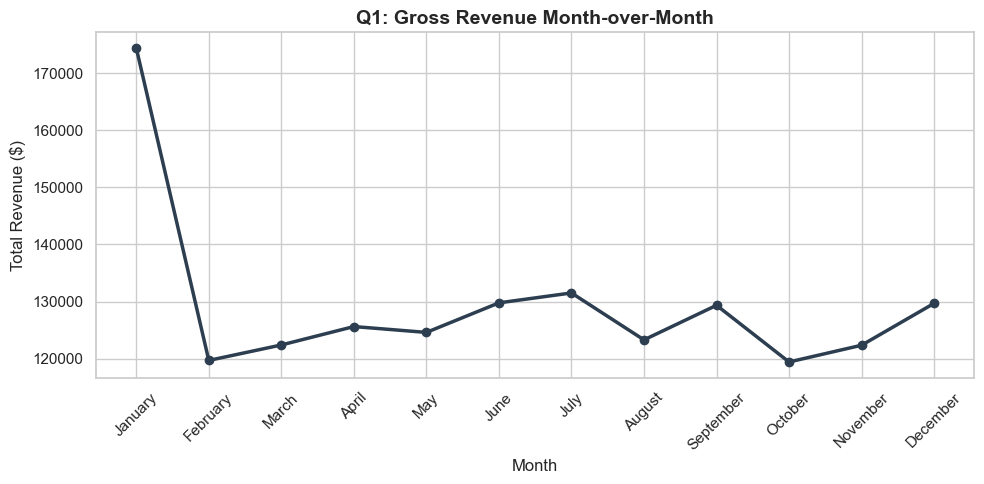

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid", palette="muted")

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
df_clean['transaction_month'] = pd.Categorical(df_clean['transaction_month'], categories=month_order, ordered=True)

plt.figure(figsize=(10, 5))
monthly_rev = df_clean.groupby('transaction_month', observed=False)['total_spent'].sum()
plt.plot(monthly_rev.index, monthly_rev.values, marker='o', linewidth=2.5, color='#2c3e50')
plt.title('Q1: Gross Revenue Month-over-Month', fontweight='bold', fontsize=14)
plt.ylabel('Total Revenue ($)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 7.1 Insights
* The `transaction_month` of January has a difference when compared to the remaining months, with `total_spent` to roughly $175,000. This indicates that customers are more likely to spend in the Initial part of the year, probably due to New Years. 
* Overall cash flow is stable throughout the year, at around ~$120k and ~$130k. 

### 7.2: How does category revenue share differ across the four financial quarters?

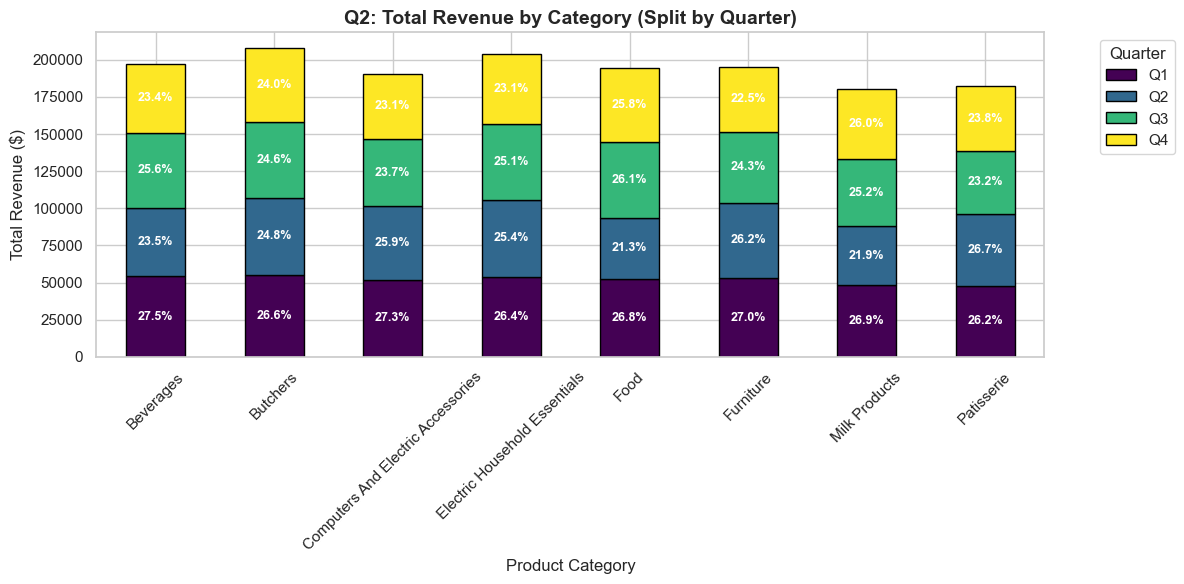

In [82]:
cat_quarter = df_clean.groupby(['category', 'transaction_quarter'])['total_spent'].sum().unstack()

totals = cat_quarter.sum(axis=1)

ax = cat_quarter.plot(kind='bar', stacked=True, colormap='viridis', figsize=(12, 6), edgecolor='black')

for c in ax.containers:
    labels = [f"{(v/total)*100:.1f}%" if v > 0 else "" for v, total in zip(c.datavalues, totals)]
    ax.bar_label(c, labels=labels, label_type='center', color='white', fontweight='bold', fontsize=9)

plt.title('Q2: Total Revenue by Category (Split by Quarter)', fontweight='bold', fontsize=14)
plt.ylabel('Total Revenue ($)')
plt.xlabel('Product Category')
plt.legend(title='Quarter', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 7.2 Insights
* "Butchers" & "Electric Household Essentials" generate the highest `total_spent`.
*  Every `category` drives almost similar revenue per quarter(hovering from 21-28%)

### 7.3: When are promotional discounts most heavily utilized throughout the year?


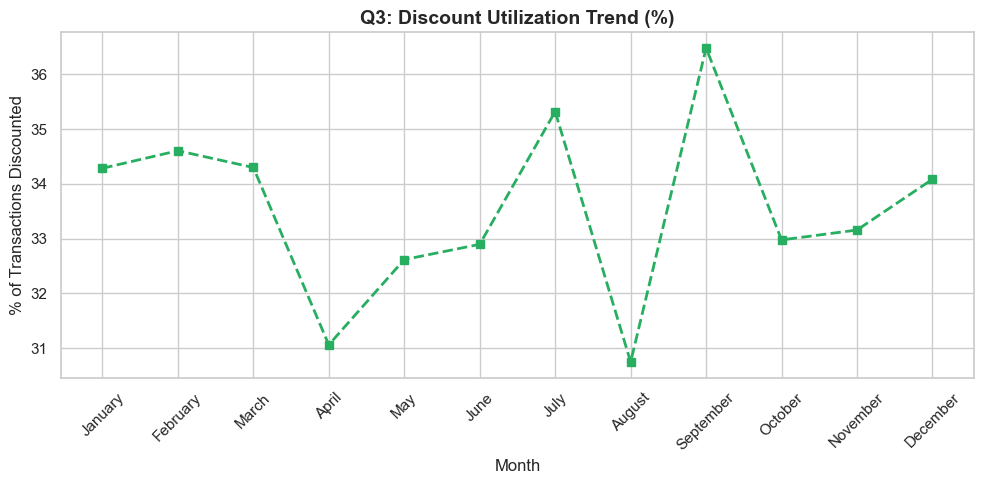

In [83]:
plt.figure(figsize=(10, 5))
monthly_discount = df_clean.groupby('transaction_month', observed=False)['discount_applied'].mean() * 100
plt.plot(monthly_discount.index, monthly_discount.values, marker='s', linestyle='--', linewidth=2, color='#27ae60')
plt.title('Q3: Discount Utilization Trend (%)', fontweight='bold', fontsize=14)
plt.ylabel('% of Transactions Discounted')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 7.3 Insights
* The `discount_applied` strategy is highly volatile compared to other datapoints/features we have in the dataset.
* Discounts are the highest at ~36.5% of transactions in September.
* Discounts drop to a year-low of ~30.5% in August. This is indicative of the promotional strategies being run by the company in September.

### 7.4: Do a small percentage of our VIP customers drive the vast majority of our total revenue?

Context: The Pareto Principle (80/20 rule) is a core consulting metric used by retail giants. If a group of customers drives most of the cash, the marketing budget should shift to those customers.

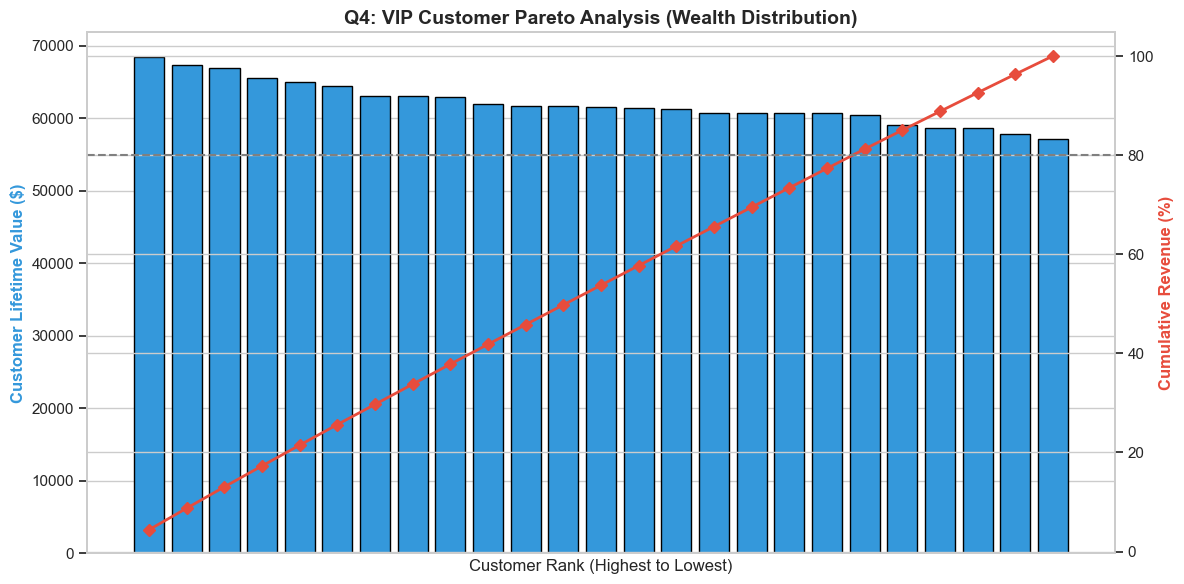

In [84]:
df_pareto = df_customer_profile.sort_values(by='customer_lifetime_value', ascending=False).copy()
df_pareto['cumulative_revenue'] = df_pareto['customer_lifetime_value'].cumsum()
df_pareto['cumulative_percentage'] = (df_pareto['cumulative_revenue'] / df_pareto['customer_lifetime_value'].sum()) * 100

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(df_pareto.index.astype(str), df_pareto['customer_lifetime_value'], color='#3498db', edgecolor='black')
ax1.set_ylabel('Customer Lifetime Value ($)', color='#3498db', fontweight='bold')
ax1.set_xlabel('Customer Rank (Highest to Lowest)')
ax1.set_xticks([])

ax2 = ax1.twinx()
ax2.plot(df_pareto.index.astype(str), df_pareto['cumulative_percentage'], color='#e74c3c', marker='D', linewidth=2)
ax2.set_ylabel('Cumulative Revenue (%)', color='#e74c3c', fontweight='bold')
ax2.axhline(80, color='gray', linestyle='--')

plt.title('Q4: VIP Customer Pareto Analysis (Wealth Distribution)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

#### 7.4 Insights
* A straight diagonal cumulative revenue line means that there is an equal wealth distribution, and there is little variance between their spending habits.
* Every `customer_id` in the dataset has almost the same `customer_lifetime_value` (~$60k-$70k). This reaffirms that our pareto analysis doesn't apply here, as there is little difference between the customers. 

### 7.5: How does our entire inventory perform when comparing sales volume against total revenue?

Caterogies-

Stars (Cash Cows), Traffic Builders (High Vol./Low Margin), and Dead Stock(Low Vol./Low Margin).

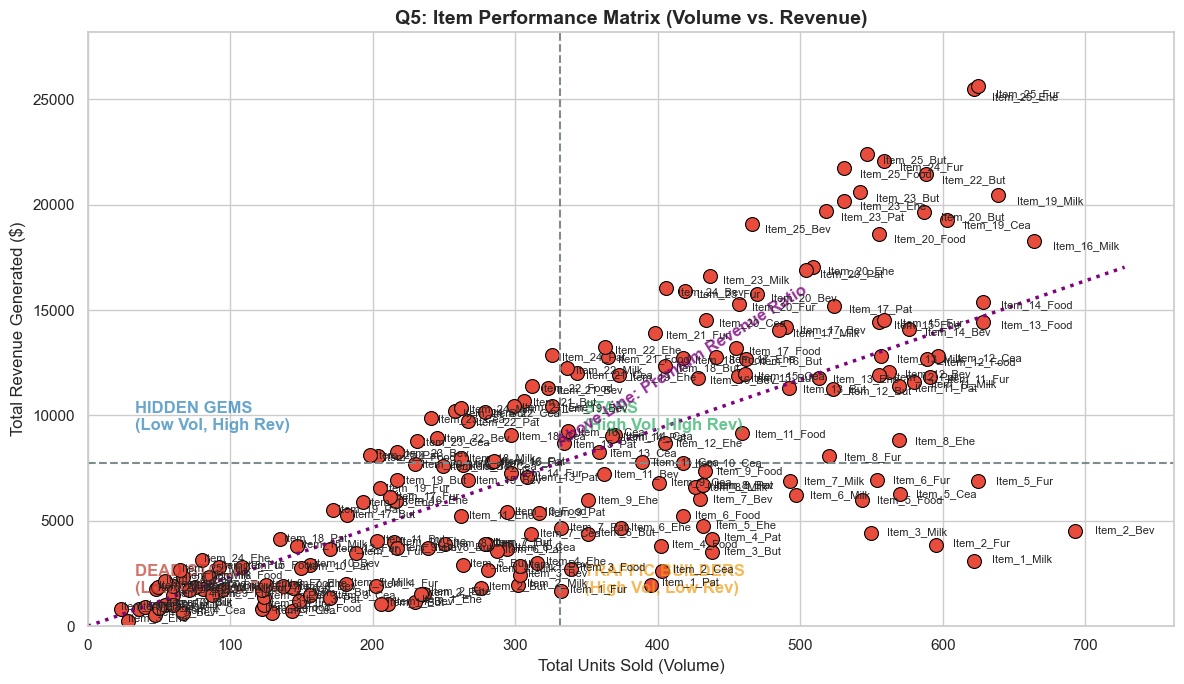

In [85]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

item_perf = df_clean.groupby('item').agg(
    total_volume=('quantity', 'sum'),
    total_revenue=('total_spent', 'sum')
).reset_index()

vol_avg = item_perf['total_volume'].mean()
rev_avg = item_perf['total_revenue'].mean()
global_ratio = item_perf['total_revenue'].sum() / item_perf['total_volume'].sum()

plt.figure(figsize=(12, 7))
sns.scatterplot(data=item_perf, x='total_volume', y='total_revenue', color='#e74c3c', edgecolor='black', s=100)

plt.axvline(vol_avg, color='#7f8c8d', linestyle='--', linewidth=1.5)
plt.axhline(rev_avg, color='#7f8c8d', linestyle='--', linewidth=1.5)

x_line = np.array([0, item_perf['total_volume'].max() * 1.05])
y_line = global_ratio * x_line
plt.plot(x_line, y_line, color='purple', linestyle=':', linewidth=2.5)

plt.text(vol_avg * 1.05, rev_avg * 1.2, 'STARS\n(High Vol, High Rev)', color='#27ae60', fontweight='bold', alpha=0.7)
plt.text(vol_avg * 0.1, rev_avg * 1.2, 'HIDDEN GEMS\n(Low Vol, High Rev)', color='#2980b9', fontweight='bold', alpha=0.7)
plt.text(vol_avg * 1.05, rev_avg * 0.2, 'TRAFFIC BUILDERS\n(High Vol, Low Rev)', color='#f39c12', fontweight='bold', alpha=0.7)
plt.text(vol_avg * 0.1, rev_avg * 0.2, 'DEAD STOCK\n(Low Vol, Low Rev)', color='#c0392b', fontweight='bold', alpha=0.7)

plt.text(x_line[-1] * 0.45, y_line[-1] * 0.5, 'Above Line: Premium Revenue Ratio', color='purple', rotation=32, fontweight='bold', alpha=0.8)

for i in range(item_perf.shape[0]):
    plt.text(item_perf['total_volume'].iloc[i] * 1.02, 
             item_perf['total_revenue'].iloc[i] * 0.98, 
             item_perf['item'].iloc[i], 
             fontsize=8)

plt.title('Q5: Item Performance Matrix (Volume vs. Revenue)', fontweight='bold', fontsize=14)
plt.xlabel('Total Units Sold (Volume)')
plt.ylabel('Total Revenue Generated ($)')
plt.xlim(0, item_perf['total_volume'].max() * 1.1)
plt.ylim(0, item_perf['total_revenue'].max() * 1.1)
plt.tight_layout()
plt.show()

#### 7.6 Insights
* The matrix shows a linear trend, meaning very few "Hidden Gems" (low `quantity`, high `total_spent`) exist.
* `item` values above the purple line indicate that these items are better in terms of a revenue:volume ratio, and generate a higher revenue even at low volumes.

### 7.6: How does revenue distribute across our engineered Price Tiers (Budget, Mid-Range, Premium)?

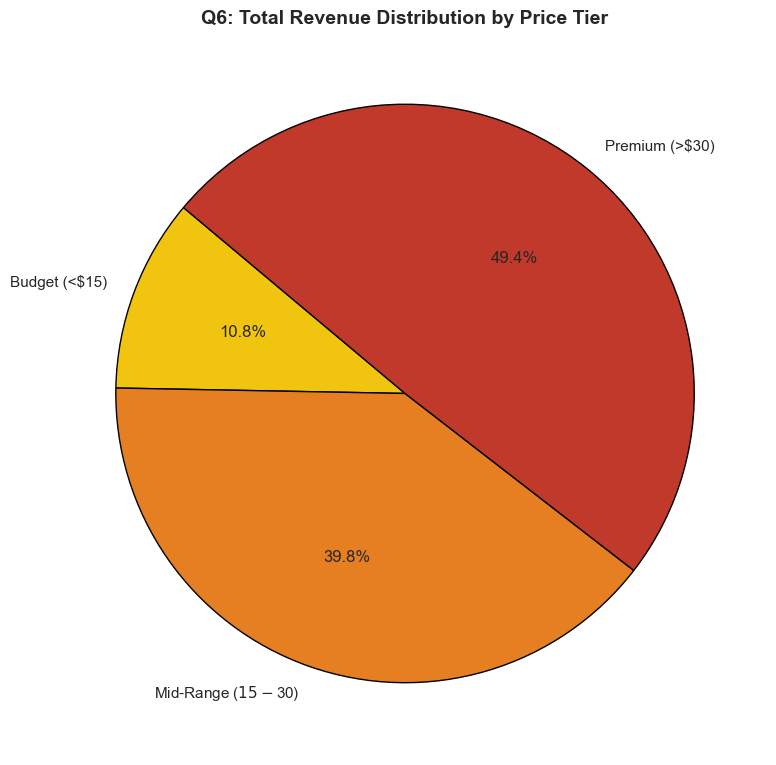

In [86]:
tier_rev = df_clean.groupby('price_tier', observed=False)['total_spent'].sum()

plt.figure(figsize=(8, 8))
plt.pie(tier_rev, labels=tier_rev.index, autopct='%1.1f%%', startangle=140, 
        colors=['#f1c40f', '#e67e22', '#c0392b'], wedgeprops={'edgecolor': 'black'})
plt.title('Q6: Total Revenue Distribution by Price Tier', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

#### 7.6 Insights
* Premium items (>$30) in our `price_tier` supports half the revenue of the business, (49.4%) of all `total_spent`.
* Budget items (<$15) only contribute to 10.8%  of sales.
* This indicates the our business functions as a premium-driven store.

### 7.7: How does revenue for each product category change across the quarters?

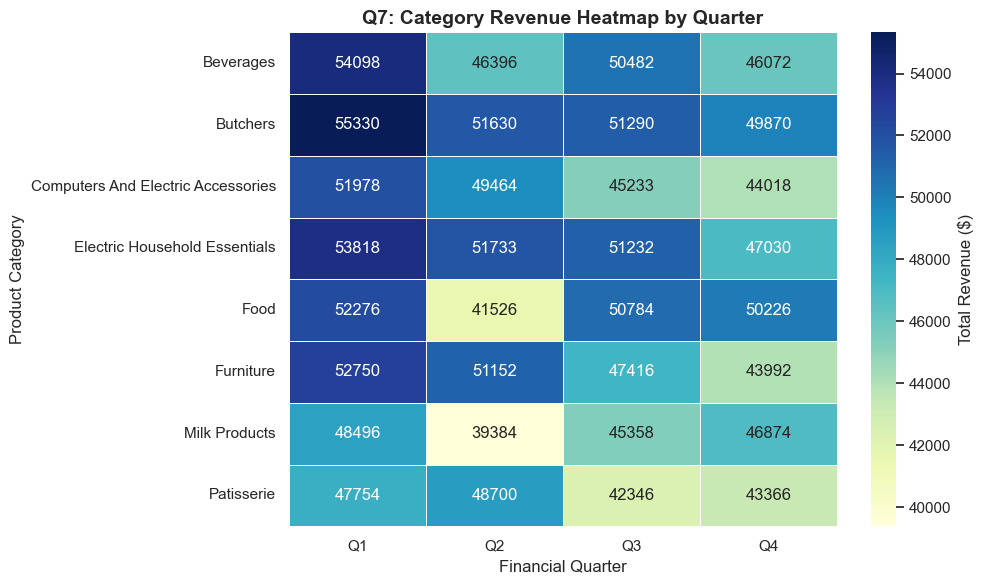

In [87]:
heatmap_data = df_clean.groupby(['transaction_quarter', 'category'])['total_spent'].sum().unstack()

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data.T, cmap='YlGnBu', annot=True, fmt='.0f', linewidths=.5, cbar_kws={'label': 'Total Revenue ($)'})
plt.title('Q7: Category Revenue Heatmap by Quarter', fontweight='bold', fontsize=14)
plt.xlabel('Financial Quarter')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

#### 7.7 Insights
* Q1 is the best  `transaction_quarter` for the business.
* Q1 total_spent is dominated by "Butchers" and "Electric Household Essentials", followed by a Q2 drop driven by "Milk Products" and "Food".

## 8.) Conclusion and Final Business Strategy

### Main Insights from the Analysis
* Sales in Quarter 1 was the highest, with the remainder of the months remaining around a similar level
* Our companies main revenue is generated from Premium Items
* Our customers spend equal amounts of money in comparision to each other

### Strengths of my Analysis
* We built custom features based on time(weekend, quarters, day of week) and we created another Dataframe for customer analysis.
* We mapped profit ratios for all items, showing us which items are generate more revenue, and which items dont. 
* We were able to fill out `items` by reverse mapping their names using existing data, which allowed to us to make approx 500 rows usable. This reduced the no. of row deletions(1200 vs 600)

### Where the data falls short
* The data is synthetic, however I chose this as this had good scope for data cleaning and feature engineering, and a lot of the situations I ran into are extremely common in real life data analysis.
* Due to its synthetic nature, the numbers are too perfect, and some of the features are completely balanced. This would not be the case however, for a real store.

### Recommendations for the Management Suite of the Company
* The management should push premium products, as they account for nearly half the revenue.
* The company should focus on Q1, and run marketing during those months as they generate most of the revenue.
* The company should focus on improving their Q3 strategy as they run the most discounts during that time, leading to a lower revenue generated in that time.

### What would improve my analysis
* Having profit margins for the products, so we have a better understanding of what really benefits the companies.
* Having a seperate table for the customers with their demographics.
* I would've preferred a more real dataset with more variance, however the analysis we perform remains the same, just the output would differ. 